# Módulo 11 — Redes Convolucionais (CNN)
**Portfólio de Laboratório de RNA**
**Aluno:** Gabriel Rocha Guimarães | **RA:** 23110134 | **Turma:** 26-1-COMP-7-07-B

---

## Fundamentação Teórica

As **CNNs** revolucionaram a visão computacional ao substituir a abordagem do MLP — que "achata" a imagem em um vetor perdendo a estrutura espacial — por operações que **preservam a localidade 2D** dos pixels.

**Operação de convolução:** um filtro $K$ de tamanho $k \times k$ desliza sobre a imagem $I$:

$$(I * K)[i,j] = \sum_{m}\sum_{n} I[i+m, j+n] \cdot K[m,n]$$

Cada filtro detecta um padrão específico (borda, textura, forma) em qualquer posição da imagem. Múltiplos filtros são aplicados em paralelo, gerando um conjunto de **feature maps**.

**Max Pooling:** reduz a resolução espacial mantendo apenas o valor máximo de cada região, introduzindo invariância translacional:

$$P[i,j] = \max_{m,n \in \text{pool}} F[i \cdot s + m,\, j \cdot s + n]$$

**Parâmetros compartilhados:** um filtro $3 \times 3$ tem apenas $9$ parâmetros, independentemente do tamanho da imagem. O mesmo filtro varre toda a imagem — isso reduz drasticamente o número de parâmetros comparado ao MLP equivalente.

**Hierarquia de representações:** camadas iniciais aprendem bordas e texturas; camadas mais profundas combinam esses elementos em formas e objetos complexos.

In [1]:
# Passo 2-3 — Convolução e Max Pooling manuais
import numpy as np

def convolve2d(image, kernel):
    i_h, i_w = image.shape
    k_h, k_w = kernel.shape
    o_h = i_h - k_h + 1
    o_w = i_w - k_w + 1
    output = np.zeros((o_h, o_w))
    for i in range(o_h):
        for j in range(o_w):
            region = image[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
    return output

def max_pool2d(feature_map, pool_size=2):
    h, w = feature_map.shape
    out_h = h // pool_size
    out_w = w // pool_size
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = feature_map[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
            output[i, j] = np.max(region)
    return output

# Demonstração: imagem com borda vertical
image = np.array([
    [1,1,0,0,0],
    [1,1,0,0,0],
    [1,1,0,0,0],
    [1,1,0,0,0],
    [1,1,0,0,0]
])
kernel_borda = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

print('Imagem (5x5):\n', image)
print('\nKernel detector de borda vertical (3x3):\n', kernel_borda)

fm = convolve2d(image, kernel_borda)
print('\nFeature map após convolução (3x3):\n', fm)

# Max Pooling
fm4 = np.array([[1,3,2,4],[5,2,1,0],[3,6,2,1],[1,4,5,2]])
pooled = max_pool2d(fm4, pool_size=2)
print('\nMax pooling 2x2 de [[1,3,2,4],[5,2,1,0],[3,6,2,1],[1,4,5,2]]:')
print(pooled)
print('4x4 → 2x2: redução de 75% dos dados mantendo valores máximos')

Imagem (5x5):
 [[1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]]

Kernel detector de borda vertical (3x3):
 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Feature map após convolução (3x3):
 [[-3. -3.  0.]
 [-3. -3.  0.]
 [-3. -3.  0.]]

Max pooling 2x2 de [[1,3,2,4],[5,2,1,0],[3,6,2,1],[1,4,5,2]]:
[[5. 4.]
 [6. 5.]]
4x4 → 2x2: redução de 75% dos dados mantendo valores máximos


In [2]:
# Passo 5 — CNN com TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models

def create_simple_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Primeiro bloco convolucional
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        # Segundo bloco convolucional
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        # Classificador
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Criando CNN para MNIST (28x28x1, 10 classes)...')
model = create_simple_cnn(input_shape=(28,28,1), num_classes=10)
model.summary()
print(f'\nTotal de parâmetros: {model.count_params():,}')
print('Parâmetros compartilhados via filtros = muito mais eficiente que MLP!')

Criando CNN para MNIST (28x28x1, 10 classes)...


/private/var/www/facul/redes-neurais/trabalho/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Total de parâmetros: 121,930
Parâmetros compartilhados via filtros = muito mais eficiente que MLP!


In [3]:
# Passo 6 — Treinamento com MNIST
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical

print('Carregando MNIST...')
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((-1,28,28,1)).astype('float32') / 255.0
test_images  = test_images.reshape((-1,28,28,1)).astype('float32') / 255.0
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat  = to_categorical(test_labels, 10)

print(f'Treino: {train_images.shape[0]} imagens | Teste: {test_images.shape[0]} imagens')
print(f'Formato: {train_images.shape[1:]}')

print('\nTreinando CNN (5 épocas)...')
history = model.fit(
    train_images, train_labels_cat,
    epochs=5,
    batch_size=128,
    validation_data=(test_images, test_labels_cat),
    verbose=1
)

test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose=0)
print(f'\nAcurácia final no teste: {test_acc*100:.2f}%')

Carregando MNIST...
Treino: 60000 imagens | Teste: 10000 imagens
Formato: (28, 28, 1)

Treinando CNN (5 épocas)...
Epoch 1/5


  1/469 ━━━━━━━━━━━━━━━━━━━━ 2:40 343ms/step - accuracy: 0.0703 - loss: 2.2789

  9/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2395 - loss: 2.2041    

 18/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3506 - loss: 2.0771

 27/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4231 - loss: 1.9183

...

445/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.0268

454/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.0268

463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.0268

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9912 - loss: 0.0275 - val_accuracy: 0.9882 - val_loss: 0.0345



Acurácia final no teste: 98.82%


Filtros da 1ª camada Conv2D: (3, 3, 1, 32)
  → 32 filtros de 3x3x1 (3x3 pixels, 1 canal)

Estatísticas dos primeiros 8 filtros:
  Filtro  1: min=-0.378, max=0.256, std=0.237
  Filtro  2: min=-0.262, max=0.230, std=0.171
  Filtro  3: min=-0.151, max=0.170, std=0.107
  Filtro  4: min=-0.308, max=0.216, std=0.163
  Filtro  5: min=-0.093, max=0.180, std=0.098
  Filtro  6: min=-0.301, max=0.179, std=0.142
  Filtro  7: min=-0.104, max=0.117, std=0.078
  Filtro  8: min=-0.216, max=0.212, std=0.142

Filtros com alto contraste detectam bordas e texturas.
Filtros uniformes detectam regiões homogêneas.
Camadas mais profundas combinam esses padrões em formas complexas.


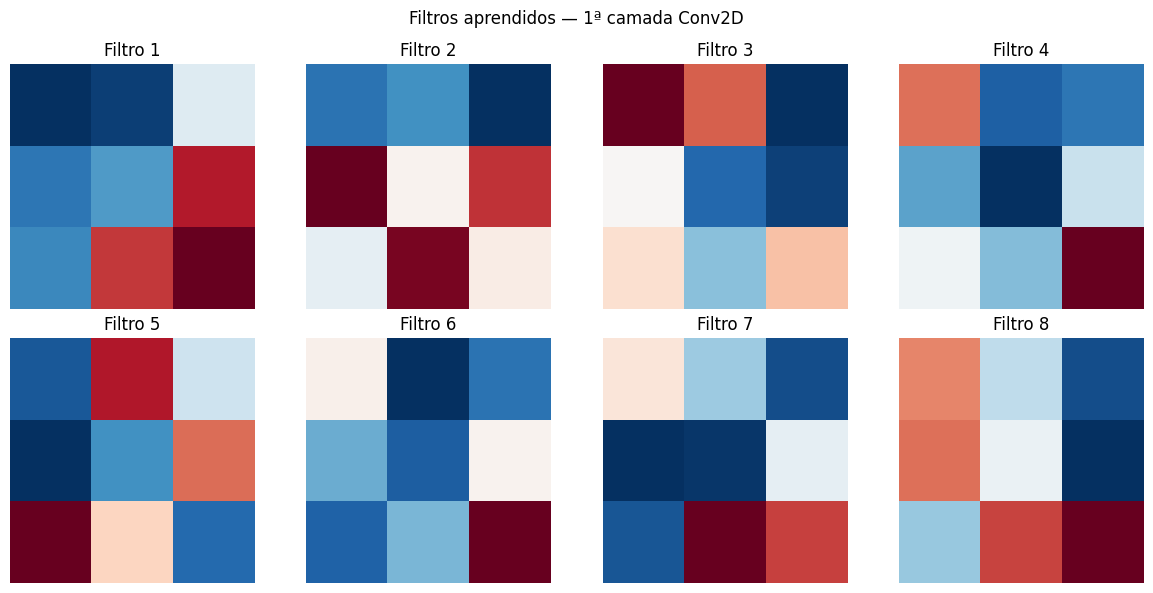

Visualização salva em filtros_cnn.png


In [4]:
# Passo 7 — Visualização dos filtros aprendidos
import numpy as np

filters, biases = model.layers[0].get_weights()
print(f'Filtros da 1ª camada Conv2D: {filters.shape}')
print(f'  → 32 filtros de 3x3x1 (3x3 pixels, 1 canal)')

f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

print('\nEstatísticas dos primeiros 8 filtros:')
for i in range(8):
    f = filters[:,:,0,i]
    print(f'  Filtro {i+1:2d}: min={f.min():.3f}, max={f.max():.3f}, std={f.std():.3f}')

print('\nFiltros com alto contraste detectam bordas e texturas.')
print('Filtros uniformes detectam regiões homogêneas.')
print('Camadas mais profundas combinam esses padrões em formas complexas.')

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i < 8:
            ax.imshow(filters_norm[:,:,0,i], cmap='RdBu')
            ax.set_title(f'Filtro {i+1}')
            ax.axis('off')
    plt.suptitle('Filtros aprendidos — 1ª camada Conv2D')
    plt.tight_layout()
    plt.savefig('filtros_cnn.png', dpi=80, bbox_inches='tight')
    plt.show()
    print('Visualização salva em filtros_cnn.png')
except Exception as e:
    print(f'(Visualização matplotlib indisponível: {e})')

## Análise Crítica

**CNN vs. MLP em imagens:** O MLP trata cada pixel como uma feature independente, ignorando a relação de vizinhança. A CNN, por sua vez, aplica filtros locais que exploram explicitamente a estrutura espacial — bordas em $(i,j)$ têm relação direta com o que está em $(i+1,j)$.

**Parâmetros compartilhados:** Um filtro $3 \times 3$ com 9 parâmetros é aplicado nas 676 posições de uma imagem $28 \times 28$. Um MLP equivalente precisaria de 676 parâmetros por neurônio na primeira camada, sem nenhuma reutilização. O compartilhamento não só economiza parâmetros como força o modelo a aprender detectores de padrões genéricos.

**Hierarquia de abstrações:** Filtros da primeira camada respondem a bordas e gradientes de cor. Filtros da segunda camada combinam esses elementos em formas geométricas. Camadas ainda mais profundas reconhecem partes de objetos. Essa hierarquia emergente é a principal razão pela qual CNNs profundas superam modelos rasos.

**Invariância translacional via pooling:** O Max Pooling reduz a sensibilidade à posição exata de um padrão — um filtro que detecta uma borda à esquerda produz a mesma resposta se a borda se deslocar alguns pixels, depois do pooling.